<a href="https://colab.research.google.com/github/vibeshvidya/Advanced-AI-ML/blob/main/Assignment_on_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AI-Driven Employee Attrition Prediction**

Objective:

The objective of this project is to build a machine learning model that predicts whether an employee will leave an organization based on various factors such as salary, job satisfaction, work-life balance, and more.

Problem Type:

This is a Supervised Machine Learning - Classification Problem.

Target variable

- Attrition:

Yes -> Employee left

No  -> Employee stayed

In [35]:
#importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [36]:
#Load Dataset

df = pd.read_csv('/content/drive/MyDrive/IIT Palakkad Advanced AI/employee_attrition_dataset.csv')
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


Data Understanding

In [37]:
#Dataset Shape

print(df.shape)

(1000, 26)


In [38]:
#Data Types

print(df.dtypes)

Employee_ID                       int64
Age                               int64
Gender                           object
Marital_Status                   object
Department                       object
Job_Role                         object
Job_Level                         int64
Monthly_Income                    int64
Hourly_Rate                       int64
Years_at_Company                  int64
Years_in_Current_Role             int64
Years_Since_Last_Promotion        int64
Work_Life_Balance                 int64
Job_Satisfaction                  int64
Performance_Rating                int64
Training_Hours_Last_Year          int64
Overtime                         object
Project_Count                     int64
Average_Hours_Worked_Per_Week     int64
Absenteeism                       int64
Work_Environment_Satisfaction     int64
Relationship_with_Manager         int64
Job_Involvement                   int64
Distance_From_Home                int64
Number_of_Companies_Worked        int64


In [39]:
#Missing Values

print(df.isnull().sum)

<bound method DataFrame.sum of      Employee_ID    Age  Gender  Marital_Status  Department  Job_Role  \
0          False  False   False           False       False     False   
1          False  False   False           False       False     False   
2          False  False   False           False       False     False   
3          False  False   False           False       False     False   
4          False  False   False           False       False     False   
..           ...    ...     ...             ...         ...       ...   
995        False  False   False           False       False     False   
996        False  False   False           False       False     False   
997        False  False   False           False       False     False   
998        False  False   False           False       False     False   
999        False  False   False           False       False     False   

     Job_Level  Monthly_Income  Hourly_Rate  Years_at_Company  ...  Overtime  \
0        Fal

In [40]:
#Duplicate Values

print("Duplicates:",df.duplicated().sum())

Duplicates: 0


Exploratory Data Analysis

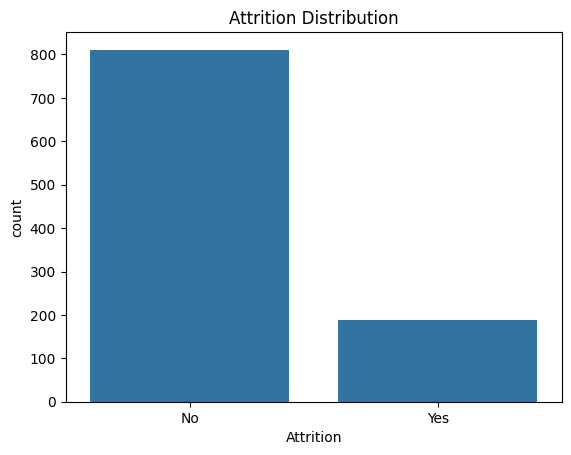

In [41]:
#Target Distribution

sns.countplot(x='Attrition',data=df)
plt.title('Attrition Distribution')
plt.show()

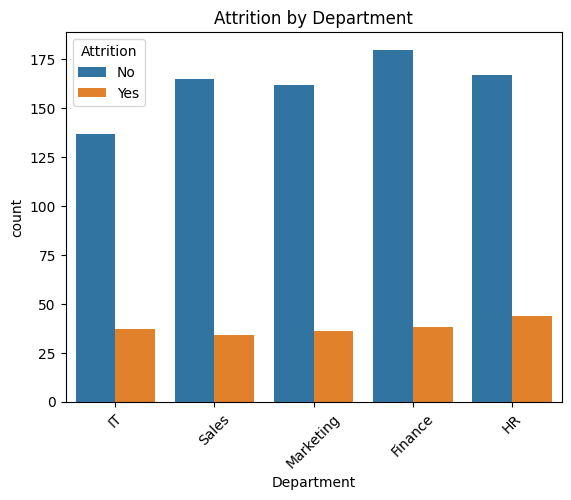

In [42]:
#Attritition by Department

sns.countplot(x='Department',hue='Attrition',data=df)
plt.xticks(rotation=45)
plt.title('Attrition by Department')
plt.show()

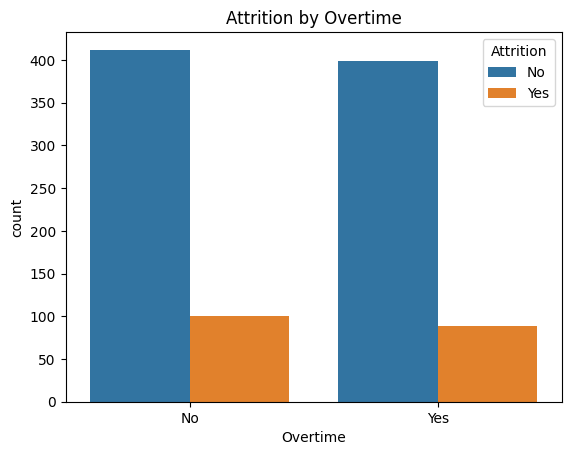

In [43]:
#Attrition by Overtime

if 'Overtime' in df.columns:
  sns.countplot(x='Overtime',hue='Attrition',data=df)
  plt.title('Attrition by Overtime')
  plt.show()

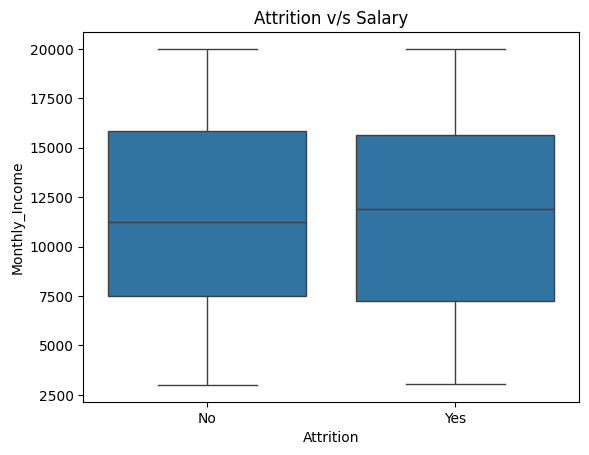

In [44]:
#Attrition v/s Salary
if 'Monthly_Income' in df.columns:
  sns.boxplot(x='Attrition', y='Monthly_Income',data=df)
  plt.title('Attrition v/s Salary')
  plt.show()

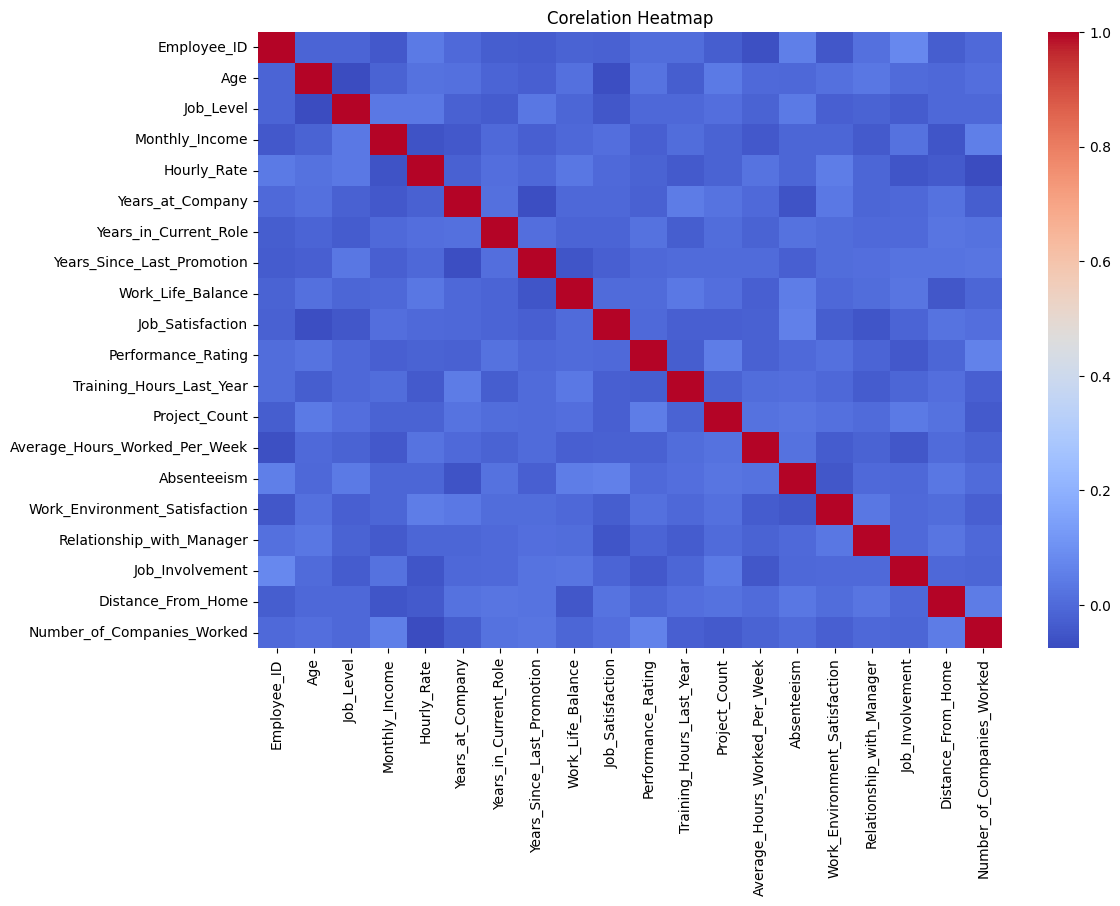

In [45]:
#Corelation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.title("Corelation Heatmap")
plt.show()


Data Preprocessing

In [46]:
#Encode target variable

df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

In [47]:
#Separate features and target

X = df.drop('Attrition',axis=1)
y = df['Attrition']

In [48]:
#Identify categorical columns

cat_cols = X.select_dtypes(include='object').columns


In [49]:
#Label encoding

for col in cat_cols:
  le= LabelEncoder()
  X[col] = le.fit_transform(X[col])


In [50]:
#Filling missing values

X = X.fillna(X.median())

In [51]:
#Train-test Split

X_train, X_test, y_train, y_test = train_test_split(
  X,y,test_size=0.2, random_state=42, stratify=y
)

Model Building

In [52]:

models = {
    "Logisitic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest" :RandomForestClassifier()
}

In [53]:
results =[]

for name, model in models.items():
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  results.append({
      "Model": name,
      "Accuracy":accuracy_score(y_test,y_pred),
      "Precision" :precision_score(y_test,y_pred),
      "Recall" :recall_score(y_test,y_pred),
      "F1 Score" :f1_score(y_test,y_pred)
  })

  results_df = pd.DataFrame(results)
  results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. 

Model Evaluation

In [55]:
for name, model in models.items():
  print(f"Model:{name}")
  y_pred = model.predict(X_test)

  print(confusion_matrix(y_test,y_pred))
  print(classification_report(y_test,y_pred))
  print("-"*50)

Model:Logisitic Regression
[[162   0]
 [ 38   0]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200

--------------------------------------------------
Model:Decision Tree
[[123  39]
 [ 24  14]]
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       162
           1       0.26      0.37      0.31        38

    accuracy                           0.69       200
   macro avg       0.55      0.56      0.55       200
weighted avg       0.73      0.69      0.70       200

--------------------------------------------------
Model:Random Forest
[[162   0]
 [ 38   0]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       162

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [57]:
#Feature Importance (Random Forest)

rf = models["Random Forest"]

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importances": importances
}).sort_values(by="Importances",ascending=False)
feat_imp.head(10)

,Feature,Importances
0,Employee_ID,0.075332
7,Monthly_Income,0.071778
8,Hourly_Rate,0.070845
15,Training_Hours_Last_Year,0.070120
23,Distance_From_Home,0.063341
18,Average_Hours_Worked_Per_Week,0.061908
19,Absenteeism,0.059056
1,Age,0.056926
9,Years_at_Company,0.051261
10,Years_in_Current_Role,0.046534


Business Insights

Key Insights

Employees working overtime are more likely to leave.

Low job satisfaction leads to higher attrition.

Employees with low salary tend to leave more.

Lack of promotions increases attrition risk.

Recommendations

Improve Work-life balance policies.

Provide career growth opportunities.

Review compensation structures.

Focus on employee engagement programs.


Conclusion

This project demonstrates how machine learning can help predict employee attrition effectively. Among the models tested, Random Forest generally provides better performance due to its ability to handle complex relationships.

The model can help HR teams proactively identify high-risk employees and take necessary actions to reduce attrition.